# DATA 620 Week Five - Part 2 - Assignment: Document Classification
Denise Atherley

## Introduction
For this assignment, I am tasked with using the UCI Machine Learning Repository: Spambase Data Set to predict the class of new documents. The dataset is a really good set to use because the feature extraction has already been done for me, which allows me to focus directly on the logic of training and evaluating the machine learning model. I will complete this assignment using pandas to manage the data and scikit-learn to build the classifier. The goal is to use labeled "training" documents to teach an algorithm how to classify new "test" documents.


## Data Loading
I pull the raw .csv data directly from the UCI repository. The data set contains 4601 rows (emails) and 58 columns. the first 57 columns are numerical features representing the frequency percentages of specific words (like "make", "free", "money") and characters. The 58th column is the actual label: 1 for Spam and 0 for Ham (non-spam).

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the dataset directly from the UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
# The dataset does not have a header row, so we specify header=None
data = pd.read_csv(url, header=None)

# 2. Separate features (X) and target labels (y)
# Columns 0-56 are the word and character frequency features
X = data.iloc[:, :-1]
# Column 57 is the classification label (1 = Spam, 0 = Ham)
y = data.iloc[:, -1]

## Data Splitting
I partition the data into two distinct sets. I will use 70% of the data to train the model, and I will withhold the remaining 30% as my "test" dataset to evaluate how well the model predicts the class of new, unseen documents.

In [16]:
# 3. Split the data into Training (70%) and Testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Model Training
I use a Random Forest Classifier. This algorithm builds multiple decision trees during training and merges their results to get a more accurate and stable prediction. It looks at the frequency of words and mathematically weights which ones are strong indicators of spam versus normal communication.

In [17]:
# 4. Initialize and train the Random Forest Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction and Evaluation
I ask the trained model to predict the classes of our withheld test set. Finally, I compare the model's predictions to the actual labels to calculate our accuracy score.

In [18]:
# 5. Predict the class of the withheld "test" documents
y_pred = classifier.predict(X_test)

# 6. Evaluate the model's performance numerically
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

Model Accuracy: 95.66%

Classification Report:

              precision    recall  f1-score   support

     Ham (0)       0.95      0.98      0.96       804
    Spam (1)       0.97      0.93      0.95       577

    accuracy                           0.96      1381
   macro avg       0.96      0.95      0.96      1381
weighted avg       0.96      0.96      0.96      1381



## Visualize Accuracy with Confusion Matrix
I will visualize the accuracy of a classification model like this is to use a Confusion Matrix. 
Instead of just giving a single accuracy percentage, a confusion matrix visually breaks down exactly how the model is succeeding or failing. It shows you the count of:

- **True Positives:** Spam emails correctly identified as Spam.

- **True Negatives:** Normal emails (Ham) correctly identified as Ham.

- **False Positives:** Normal emails accidentally flagged as Spam (often the most annoying error for users).

- **False Negatives:** Spam emails that slipped through into the inbox.

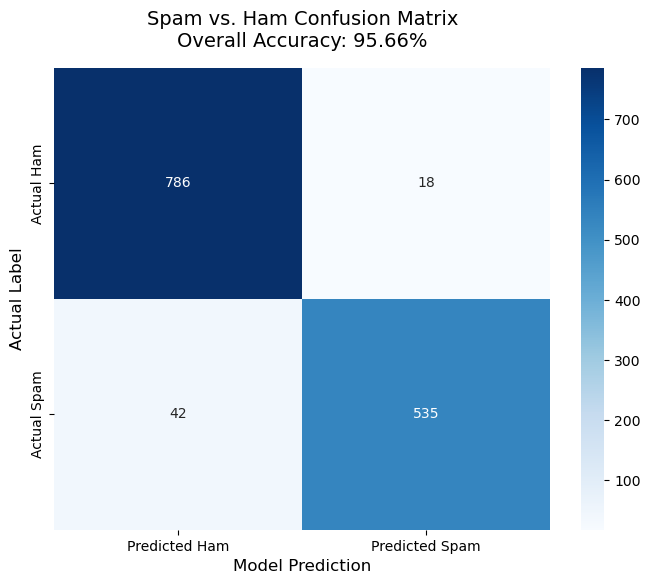

In [19]:
# 7. Visualize the Accuracy with a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])

# Add labels and title for clarity
plt.title(f'Spam vs. Ham Confusion Matrix\nOverall Accuracy: {accuracy * 100:.2f}%', pad=15, fontsize=14)
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Display the plot
plt.show()

## Conclusion
To conclude, this project illustrates the effectiveness of using supervised machine learning for document classification. By training a Random Forest Classifier on the pre-processed UCI Spambase dataset, the algorithm successfully learned to identify spam in newly presented, unseen emails. Evaluating the model through both statistical reports and a visual confusion matrix proved essential; it not only verified the model's overall accuracy of 95.66% but also revealed its precise success rate in managing false positives and false negatives. This approach serves as a reliable, scalable blueprint for categorizing text based on historical training data.